This is example showing generation of IFCs  using hiphive code using machine learning models. Requires phonopy. hiphive and related libraries.


In [18]:
 # Setup plotting, seaborn is just used to make figures look a bit nicer not required
%matplotlib inline
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_context('talk')
except ModuleNotFoundError:
    print('Dont worry')

In [19]:
import numpy as np
from ase.io import read
from ase.db import connect
from hiphive import ClusterSpace, StructureContainer
from hiphive.utilities import get_displacements
from trainstation import Optimizer
from hiphive import ClusterSpace, StructureContainer, ForceConstantPotential
from phonopy import Phonopy
from phonopy.structure.atoms import PhonopyAtoms
from ase import Atoms

Lets describe the cutoff paramters here. convergence should be check wrt to these parameters.

In [37]:
cutoffs = [12.3]
cutoffs_str = str(cutoffs)[1:-1].replace(', ', '_')
sc_fname = 'sc_cutoffs-{}.sc'.format(cutoffs_str)

Setup cluster space and Structure Container. And Feed raw data training structures from DFT simulations which is stored as ase data base.

In [36]:
atoms_ideal = read('./POSCAR_ideal')
cs = ClusterSpace(atoms_ideal, cutoffs)
sc = StructureContainer(cs)
db = connect('./CsSnI.db')

for row in db.select():

    # get displacements and forces
    atoms = row.toatoms()
    forces = atoms.get_forces()
    displacements = get_displacements(atoms, atoms_ideal)

    # sanity check
    max_disp = np.max(np.linalg.norm(displacements, axis=1))
    #print(max_disp)
    # as the snapshot are from AIMD run -the max disp is but higher 
    #assert max_disp < 0.95

    # add atoms to StructureContainer
    atoms.positions = atoms_ideal.get_positions()
    atoms.new_array('forces', forces)
    atoms.new_array('displacements', displacements)
    sc.add_structure(atoms)

# write to file
sc.write(sc_fname)

Primitive cell:
    Formula: Cs2I6Sn
    Cell:
        [  0.00000   5.83899   5.83899]
        [  5.83899   0.00000   5.83899]
        [  5.83899   5.83899   0.00000]
    Basis:
        Cs  [  0.25000   0.25000   0.25000]
        Cs  [  0.75000   0.75000   0.75000]
        Sn  [  0.00000   0.00000   0.00000]
        ...

Crystal symmetry:
    Spacegroup:          Fm-3m (225)
    Unique site:         3
    Symmetry operations: 48
    symprec:             1.00e-05

Cutoffs:
    Maximum cutoff: 12.3
    Found 9 center atoms with 363 images totaling 372 atoms

Clusters:
    Clusters: {2: 1440, 3: 800}
    Total number of clusters: 2240

Orbits:
    Orbits: {2: 41, 3: 28}
    Total number of orbits: 69

Eigentensors:
    Eigentensors: {2: 176, 3: 206}
    Total number of parameters: 382
    Discarded orbits:
        (2, 2, 2)

Constraints:
    Acoustic: True
    Number of degrees of freedom: {2: 172, 3: 158}
    Total number of degrees of freedom: 330


Lets use the structure container from above to get IFCs

In [34]:
dim = np.diag([3,3,3])
prim = read('POSCAR')
atoms_ideal = read('POSCAR_ideal')

In [50]:
fit_methods = ['least-squares', 'rfe', 'ardr']#, 'lasso']
cutoffs1 = [[12.3, 6.0]]  # add  more to check
for cutoffs in cutoffs1:
    cutoffs_str = str(cutoffs)[1:-1].replace(', ', '_')
    print(cutoffs_str)
    sc_fname = 'sc_cutoffs-{}.sc'.format(cutoffs_str)
    sc = StructureContainer.read(sc_fname)
    cs = sc.cluster_space
    for fit_method in fit_methods:
        tag = '{}_cutoffs-{}'.format(fit_method, cutoffs_str)
        print('Running opt for {}'.format(tag))    
        opt_n = 'opt_{}'.format(tag)
        opt_n = Optimizer(sc.get_fit_data(),  fit_method=fit_method, train_size=0.8)
        opt_n.train()
        #print(opt_n)      
        print('test  error: {:10.6f} (eV/Å)'.format(opt_n.rmse_test))
        print('train error: {:10.6f} (eV/Å)'.format(opt_n.rmse_train))
        #sd = opt_n.scatter_data_test
        #fig = plt.figure(figsize=(7.5, 6))
        #plt.plot(sd.target, sd.predicted, 'o')   
        #plt.xlabel('Target forces (eV/Å)')
        #plt.ylabel('Predicted forces (eV/Å)');
        fcp_fname = 'fcp_{}.fcp'.format(tag)
        params = opt_n.parameters
        fcp = ForceConstantPotential(cs, params)
        fcp.write(fcp_fname)

12.3_6.0
Running opt for least-squares_cutoffs-12.3_6.0
test  error:   0.043369 (eV/Å)
train error:   0.044027 (eV/Å)
Running opt for rfe_cutoffs-12.3_6.0
test  error:   0.043370 (eV/Å)
train error:   0.044028 (eV/Å)
Running opt for ardr_cutoffs-12.3_6.0
test  error:   0.044085 (eV/Å)
train error:   0.044776 (eV/Å)


least-squares_cutoffs-12.3_6.0
rfe_cutoffs-12.3_6.0
ardr_cutoffs-12.3_6.0


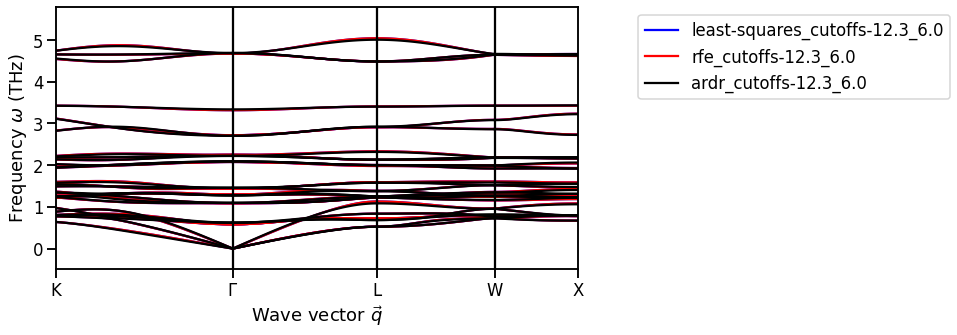

In [54]:
fig = plt.figure(figsize=(14, 5))
c=['b', 'r', 'k']

Nq = 51 
def get_band(q_start, q_stop, N):
    """ Return path between q_start and q_stop """
    return np.array([q_start + (q_stop-q_start)*i/(N-1) for i in range(N)])


# setup band path

K2G = get_band(np.array([0.375, 0.375, 0.750]), np.array([0.0, 0.0, 0]), Nq)
G2L = get_band(np.array([0.0, 0.0, 0.0]), np.array([0.5, 0.5, 0.5]), Nq)
L2W = get_band(np.array([0.5, 0.5, 0.5]), np.array([0.5, 0.250, 0.750]), Nq)
W2X = get_band(np.array([0.5, 0.250, 0.750]), np.array([0.5, 0.0, 0.5]), Nq)
bands = [K2G, G2L, L2W, W2X]

atoms_phonopy = PhonopyAtoms(symbols=prim.get_chemical_symbols(),
                             scaled_positions=prim.get_scaled_positions(),
                             cell=prim.cell)
phonopy = Phonopy(atoms_phonopy, supercell_matrix=dim,
                  primitive_matrix=None)


supercell = phonopy.get_supercell()
supercell = Atoms(cell=supercell.cell, numbers=supercell.numbers, pbc=True,
                  scaled_positions=supercell.get_scaled_positions())


for i in range(0,3):
    fit_method=fit_methods[i]
    tag = '{}_cutoffs-{}'.format(fit_method, cutoffs_str)
    print(tag)
    fcp_fname = 'fcp_{}.fcp'.format(tag)
    fcp = ForceConstantPotential.read(fcp_fname)
    fcs = fcp.get_force_constants(supercell)   
 # get second order force constants
    fc2 = fcs.get_fc_array(order=2)
    phonopy.set_force_constants(fc2)
#print(fc2.shape)
# get phonon dispersion
    phonopy.set_band_structure(bands)
    qvecs, qnorms, freqs, _ = phonopy.get_band_structure()
    for q, freq, in zip(qnorms, freqs):
        plt.plot(q, freq, color=c[i])
        
    plt.plot(np.nan, np.nan, color=c[i], label=tag)    
    

kpts = [0.0, qnorms[0][-1], qnorms[1][-1], qnorms[2][-1], qnorms[3][-1]]
kpts_labels = ['K', '$\\Gamma$', 'L', 'W', 'X']
plt.xlabel('Wave vector $\\vec{q}$')
plt.ylabel('Frequency $\\omega$ (THz)')
plt.axvline(x=kpts[1], color='k')
plt.axvline(x=kpts[2], color='k')
plt.axvline(x=kpts[3], color='k')
plt.xticks(kpts, kpts_labels)
plt.xlim([0.0, qnorms[-1][-1]])
plt.ylim([-0.5, 5.8])
plt.legend(bbox_to_anchor=(1.1,1.0))
plt.tight_layout()

# compute IFCs for phonopy
#phonopy.set_force_constants(fc2)



Now lets plot the dispersion.

All done for now. WE need check convergence with respect to cutoff, and need to check for overfitting.